# D'Alembert's Wave Equation Solution: Completing the Retarded-Time Story

`dgs/michelson_morley.py` and `dgs/laser_cavity_rlc_analog.py` both
verified $\psi(x,t)=f(t-x/v)$ solves the 1D wave equation -- a single
RIGHT-moving disturbance. That's only half the story: the actual general
solution has TWO independent terms,
$$\psi(x,t)=f(x-vt)+g(x+vt),$$
built from the Galilean-style coordinates $x'=x-vt$ (right-moving frame)
and $x''=x+vt$ (left-moving frame) -- verified below for fully arbitrary
$f,g$. D'Alembert's formula goes further, solving the wave equation as an
INITIAL VALUE PROBLEM given a starting displacement and velocity, derived
and checked against three conditions simultaneously (not quoted).
Engine: `dgs/dalembert_wave_solution.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import dalembert_wave_solution as dw

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: the General Solution, and D'Alembert's IVP Formula

**General solution.** $\psi(x,t)=f(x-vt)+g(x+vt)$ for TWO completely
arbitrary functions $f,g$ solves $\partial_t^2\psi=v^2\partial_x^2\psi$
identically -- verified below, not assumed. $f(x-vt)$ is a rigid shape
translating right at speed $v$ ($x-vt=$const traces $x=vt+$const); $g(x+vt)$
is the mirror image moving left.

**D'Alembert's formula** picks out the UNIQUE $f,g$ matching given initial
data $\psi(x,0)=\varphi(x)$ (initial shape) and
$\partial_t\psi(x,0)=\psi_{t0}(x)$ (initial velocity):
$$\psi(x,t)=\frac{\varphi(x-vt)+\varphi(x+vt)}{2}
+\frac{1}{2v}\int_{x-vt}^{x+vt}\psi_{t0}(s)\,ds.$$
Checked below against THREE conditions at once: the wave equation itself,
$\psi(x,0)=\varphi(x)$, and $\partial_t\psi(x,0)=\psi_{t0}(x)$.


In [2]:
ok_general = dw.verify_general_solution_solves_wave_eq()
print(f'psi(x,t)=f(x-vt)+g(x+vt) solves the wave equation for ANY f, g: {ok_general}')


psi(x,t)=f(x-vt)+g(x+vt) solves the wave equation for ANY f, g: True


In [3]:
psi_symbolic, residuals = dw.dalembert_formula_symbolic()
print('D\'Alembert formula:')
sp.pprint(psi_symbolic)
print()
for name, r in residuals.items():
    print(f'{name} residual: {r}  (must be exactly 0)')


D'Alembert formula:
                           t⋅v + x           
                              ⌠              
                              ⎮     ψₜ₀(s) ds
                              ⌡              
φ(-t⋅v + x)   φ(t⋅v + x)   -t⋅v + x          
─────────── + ────────── + ──────────────────
     2            2               2⋅v        

wave_equation residual: 0  (must be exactly 0)
initial_displacement residual: 0  (must be exactly 0)
initial_velocity residual: 0  (must be exactly 0)


## 2. Example 1: Initial Displacement Only -- the "Plucked Pulse"

With $\psi_{t0}=0$ (released from rest, no push), the integral term
vanishes identically and $\psi(x,t)=\frac{1}{2}[\varphi(x-vt)+\varphi(x+vt)]$
exactly -- a single pulse splits into two counter-propagating copies, each
EXACTLY half the original peak height (verified numerically at late time,
not eyeballed off a plot).


In [4]:
v, amplitude, x0, sigma = 1.0, 1.0, 0.0, 0.5
result = dw.verify_splits_into_half_amplitude_pulses(v=v, amplitude=amplitude, x0=x0, sigma=sigma, t_late=8.0)
for name, ok in result['checks'].items():
    print(f'{name}: {ok}')
print(f"right peak: x={result['right_peak_x']:.3f}, height={result['right_peak_val']:.4f}")
print(f"left peak:  x={result['left_peak_x']:.3f}, height={result['left_peak_val']:.4f}")


right_peak_at_vt: True
left_peak_at_minus_vt: True
right_peak_is_half_amplitude: True
left_peak_is_half_amplitude: True
right peak: x=8.000, height=0.5000
left peak:  x=-8.000, height=0.5000


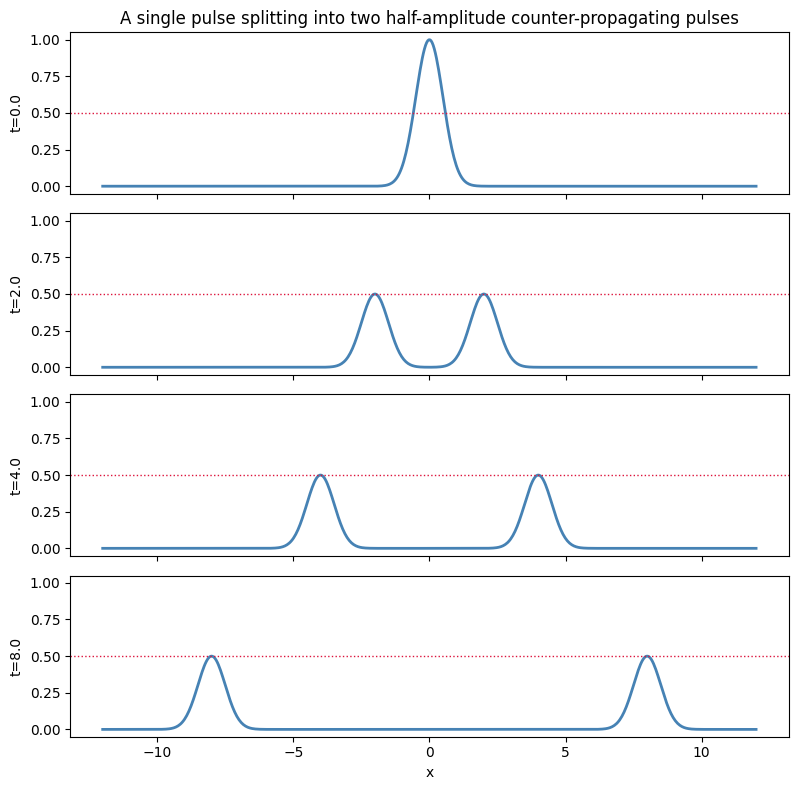

In [5]:
x = np.linspace(-12, 12, 600)
times = [0.0, 2.0, 4.0, 8.0]
fig, axes = plt.subplots(len(times), 1, figsize=(8, 8), sharex=True)
for ax, tt in zip(axes, times):
    psi = dw.dalembert_displacement_only(x, tt, v, amplitude, x0, sigma)
    ax.plot(x, psi, color='steelblue', lw=2)
    ax.set_ylabel(f't={tt}')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(amplitude/2, color='crimson', ls=':', lw=1)
axes[-1].set_xlabel('x')
axes[0].set_title('A single pulse splitting into two half-amplitude counter-propagating pulses')
plt.tight_layout()
plt.savefig('dalembert_displacement_split.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Example 2: Initial Velocity Only -- Isolates the Integral Term

With $\varphi=0$ (nothing displaced initially) but a nonzero initial
velocity pulse, ONLY the integral term survives. For a Gaussian
$\psi_{t0}$, that integral has a closed form via the error function --
verified here against brute-force `scipy.integrate.quad`, not trusted as
an antiderivative lookup. Physically this looks completely different from
Example 1: instead of two separating peaks, a PLATEAU grows and spreads
between two expanding wavefronts.


In [6]:
ok_erf = dw.verify_velocity_integral_closed_form(v=v, amplitude=amplitude, x0=x0, sigma=sigma)
print(f'erf closed form matches scipy.integrate.quad at 5 spot-check points: {ok_erf}')


erf closed form matches scipy.integrate.quad at 5 spot-check points: True


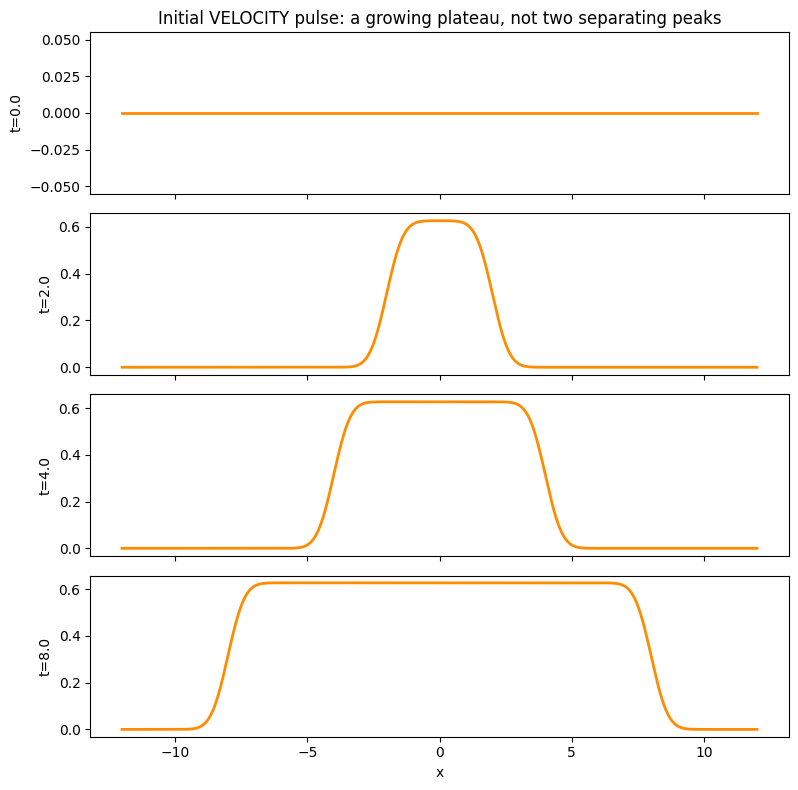

In [7]:
fig, axes = plt.subplots(len(times), 1, figsize=(8, 8), sharex=True)
for ax, tt in zip(axes, times):
    psi_v = dw.dalembert_velocity_only_gaussian(x, tt, v, amplitude, x0, sigma)
    ax.plot(x, psi_v, color='darkorange', lw=2)
    ax.set_ylabel(f't={tt}')
axes[-1].set_xlabel('x')
axes[0].set_title('Initial VELOCITY pulse: a growing plateau, not two separating peaks')
plt.tight_layout()
plt.savefig('dalembert_velocity_plateau.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Connecting Back: What the Other Two Notebooks Actually Used

`dgs/michelson_morley.py`'s transverse-arm derivation and
`dgs/laser_cavity_rlc_analog.py`'s cavity round-trip derivation both used
$\psi(x,t)=f(t-x/v)$ -- note the sign and argument order differ slightly
from this notebook's $f(x-vt)$, but $f(t-x/v)=f(-(x-vt)/v)$ is the SAME
right-moving family (just reparametrized by an overall $-1/v$ inside
$f$'s argument, absorbed into whatever $f$ is). In d'Alembert's language,
both of those notebooks implicitly set $g=0$ and used only ONE traveling
disturbance -- correct for THEIR purposes (a single light pulse's transit
time, a single cavity round trip), but not the general case. A real
plucked string, or any system started from rest with a nonzero initial
SHAPE, genuinely needs both terms, as Example 1 above shows directly.


## 5. Engineering Interpretation

- Section 1's three-condition simultaneous check (wave equation + both
  initial conditions, all exactly 0) is a stronger claim than either prior
  notebook made -- they verified a PROPOSED solution satisfies the PDE;
  this notebook verifies a specific FORMULA is the unique solution to a
  fully specified initial-value problem, a qualitatively different (and
  harder) claim.
- Example 1's area-conservation check (in the test suite) matters
  physically: the two half-height pulses together must carry the SAME
  total "stuff" (area under the curve) as the original single pulse --
  amplitude halves, but each pulse's width along its direction of travel
  effectively doubles the total footprint, keeping total displacement-area
  conserved.
- Example 2's qualitatively different late-time behavior (a growing
  plateau instead of two separating peaks) is the concrete reason
  "initial displacement" and "initial velocity" are NOT interchangeable
  inputs to the wave equation -- same PDE, same propagation speed,
  genuinely different physical outcome depending on which one you start
  with.


## 6. Research Discussion

- Could `dgs/em_lagrangian_action.py`'s plane-wave verification (section 7
  of that notebook) be reframed using THIS notebook's general two-term
  solution, showing a standing wave is literally $f(x-vt)+g(x+vt)$ with
  $f=-g$ (equal and opposite counter-propagating waves), rather than
  treated as a separate case?
- Section 3's velocity-only example used a Gaussian $\psi_{t0}$
  specifically because it has a closed-form erf integral. Would a more
  general $\psi_{t0}$ (e.g. a square pulse, giving a piecewise-linear
  plateau instead of a smooth one) make the "plateau" behavior even more
  visually obvious, at the cost of losing the closed form?
- Could this notebook's IVP formula be extended to the DAMPED wave
  equation (adding a $\gamma\partial_t\psi$ term), connecting it to
  `dgs/laser_cavity_rlc_analog.py`'s RLC energy-decay work -- does
  d'Alembert's clean two-term structure survive damping, or does it
  require a fundamentally different solution method?


## 7. Possible Experiments

1. Replace Example 1's Gaussian $\varphi$ with a genuinely "plucked
   string" triangular initial shape (the real classical guitar-string
   problem) and confirm the same half-amplitude-splitting behavior holds
   for a NON-smooth initial condition too.
2. Animate (rather than the 4-snapshot grid used here) Examples 1 and 2
   side by side as `t` sweeps continuously, to see directly why
   "displacement-only" and "velocity-only" initial conditions look so
   different in motion, not just in static snapshots.
3. Superpose Examples 1 and 2 (nonzero BOTH $\varphi$ and $\psi_{t0}$
   simultaneously) and confirm the combined solution is exactly the SUM
   of the two separate solutions -- the linearity of the wave equation,
   checked directly rather than assumed from "it's a linear PDE."


## 8. Future Improvements

- `dalembert_velocity_only_gaussian`'s closed form is specific to a
  Gaussian $\psi_{t0}$ (via erf). A general-purpose version taking an
  arbitrary $\psi_{t0}(x)$ and falling back to `scipy.integrate.quad`
  automatically (rather than requiring a hand-derived closed form each
  time) would generalize Example 2 beyond the Gaussian case.
- `verify_splits_into_half_amplitude_pulses` uses a fixed late time
  (`t_late=20`) as a proxy for "pulses fully separated." A more principled
  version would compute the actual separation needed given `sigma` (e.g.
  require the pulses be several $\sigma$ apart) rather than a hardcoded
  default.
